# Ноутбук 02 — Признаки и сравнение моделей
## Notebook 02 — Features & model comparison

**О чём ноутбук / what's inside:**
1. Создаём признаки (под-блоки А и Б) — код вынесен в `src/titanic_utils.py`.
2. Проверяем признаки статистикой: Mutual Information, Cramér's V, корреляции.
3. Сравниваем 6 моделей честно (CV + test). Финал по заданию — лес.

**Правила:** split 80/20 `random_state=42`; препроцессинг учится только на train (нет утечки); колонки `boat`/`body`/`home.dest` выброшены (см. ноутбук 01).

In [ ]:
# === Все импорты в одном месте / all imports in one place ===
import sys, pathlib
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay, classification_report)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Подключаем общий модуль проекта / import shared project module
p = pathlib.Path.cwd()
ROOT = next((q for q in [p, *p.parents] if (q / 'src' / 'titanic_utils.py').exists()), p)
sys.path.insert(0, str(ROOT / 'src'))
import titanic_utils as tu

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)

df = tu.load_data(); y = tu.get_target(df)
d = tu.add_features(df)              # добавляет признаки А+Б / adds A+B features
print('новые признаки / new features:', [c for c in d.columns if c not in df.columns])

## 1. Признаки по под-блокам / Feature sub-blocks

**Теория.** Хорошие признаки важнее сложной модели. Делим их на группы:
- **А — Классика:** `Title` (титул из имени), `pclass`, `sex`, `age`, `fare`, `embarked`, `FamilySize`, `IsAlone`, `Deck`, `HasCabin`.
- **Б — Наши идеи:** `FarePerPerson` (цена на человека = `fare` / размер группы по билету), `TicketGroupSize`, `CabinCount`, `TicketPrefix`, `SexPclass` (пол×класс), `AgeMissing`, `IsChild`, `IsMother`.
- **Г — на проверку:** `NameLength` (длина имени, вероятно шум).

Код всех признаков — в одном месте (`src/titanic_utils.py: add_features`), чтобы ноутбук и финальный скрипт считали одинаково.

In [2]:
d[['Title', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'FarePerPerson',
   'Deck', 'CabinCount', 'TicketPrefix', 'SexPclass', 'IsChild', 'IsMother']].head()

,Title,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,Deck,CabinCount,TicketPrefix,SexPclass,IsChild,IsMother
0,Miss,1,1,4,52.834375,B,1,NONE,female_1,0,0
1,Master,4,0,6,25.258333,C,2,NONE,male_1,1,0
2,Miss,4,0,6,25.258333,C,2,NONE,female_1,1,0
3,Mr,4,0,6,25.258333,C,2,NONE,male_1,0,0
4,Mrs,4,0,6,25.258333,C,2,NONE,female_1,0,1


## 2. Split 80/20 — до анализа, чтобы не подсматривать в тест
Делим выборку первой, и весь анализ ниже считаем только на train.

In [ ]:
X = d[tu.ALL_FEATURES]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=tu.RANDOM_STATE)
print('train:', X_train.shape, '| test:', X_test.shape)

## 3. Статистическая проверка признаков / Statistical checks

**Теория.**
- **Mutual Information** — насколько признак вообще связан с целью (ловит и нелинейные связи). Главная проверка «есть ли сигнал».
- **Cramér's V** — сила связи категориального признака с целью (0..1).
- **Корреляции между признаками** — ищем дубли (например `FamilySize` ≈ `sibsp+parch`).

**Важно:** это одиночные проверки. Лес использует сочетания признаков, поэтому низкая связь ≠ бесполезный признак. Это подсказки, а не приговор.

**Theory.** Mutual Information = does a feature carry signal about the target (captures non-linear links). Cramér's V = strength of a categorical link. Feature correlations = find duplicates. These are single-feature hints, not a verdict.

In [ ]:
# Кодируем для MI: числа -> медиана train, категории -> целые коды.
# Encode for MI: numbers -> train median, categories -> integer codes.
BIN = ['IsAlone', 'HasCabin', 'AgeMissing', 'IsChild', 'IsMother']
enc = pd.DataFrame(index=X_train.index)
for c in tu.NUM_FEATURES:
    enc[c] = X_train[c].fillna(X_train[c].median())
for c in tu.CAT_FEATURES:
    enc[c] = pd.factorize(X_train[c])[0]
discrete = [c in tu.CAT_FEATURES or c in BIN for c in enc.columns]
mi = pd.Series(mutual_info_classif(enc, y_train, discrete_features=discrete, random_state=tu.RANDOM_STATE),
               index=enc.columns).sort_values(ascending=False)
ax = mi.sort_values().plot.barh(figsize=(8, 6), color='mediumseagreen')
ax.set_title('Mutual Information с целью / with target')
plt.tight_layout(); plt.show()
print(mi.round(4))

In [ ]:
def cramers_v(a, b):
    """Сила связи категории с целью, 0..1 / categorical association."""
    t = pd.crosstab(a, b); chi2 = chi2_contingency(t)[0]
    n = t.values.sum(); r, k = t.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cv = pd.Series({c: cramers_v(X_train[c], y_train) for c in tu.CAT_FEATURES}).sort_values(ascending=False)
print("Cramér's V (категориальные vs survived):"); print(cv.round(3))

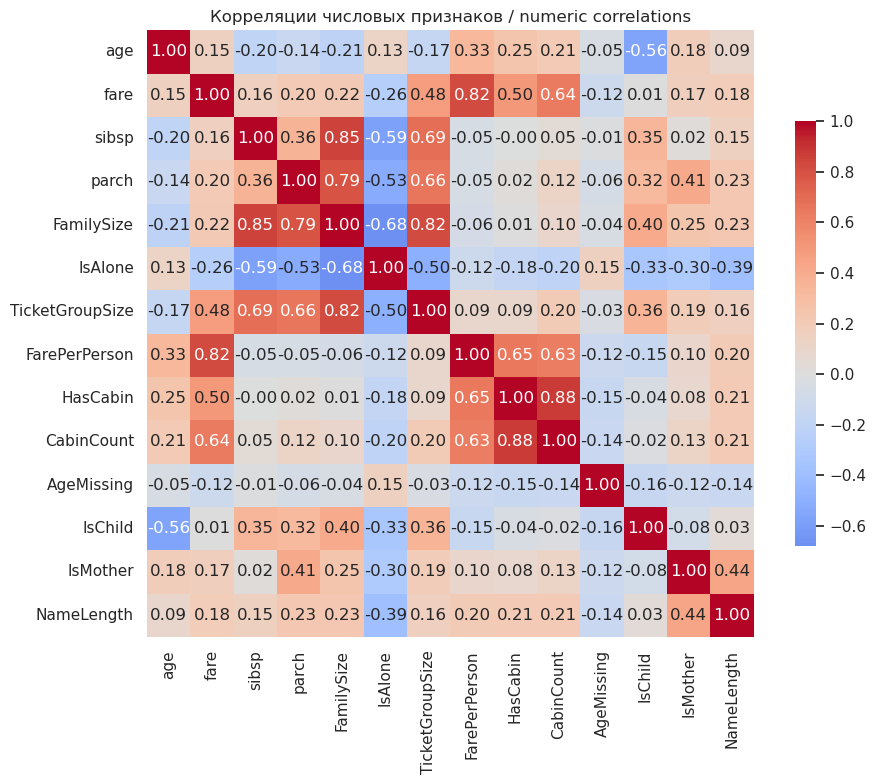

In [6]:
# Корреляции между числовыми признаками / correlations among numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(enc[tu.NUM_FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': .7})
plt.title('Корреляции числовых признаков / numeric correlations')
plt.tight_layout(); plt.show()

**Вывод.** Самые сильные признаки по Mutual Information: `SexPclass` (0.21), `Title` (0.16), `sex` (0.15), `fare` (0.12), `FarePerPerson` (0.11). По Cramér's V то же: `SexPclass` 0.62, `Title` 0.56, `sex` 0.53. `NameLength` слабый (MI ≈ 0.06) — кандидат на выброс. На тепловой карте видны ожидаемые дубли (`FamilySize`↔`sibsp/parch`, `FarePerPerson`↔`fare`); лес к дублям устойчив, поэтому удалять их не обязательно.

**Conclusion.** Strongest by MI: `SexPclass`, `Title`, `sex`, `fare`, `FarePerPerson`. `NameLength` is weak. Expected duplicates appear in the heatmap, but the forest tolerates them.

## 4. Сравнение моделей / Model comparison

**Теория.** Сравниваем 6 моделей по 5-fold CV (на train) и на тесте. Цель — убедиться, что лес (наш финал по заданию) выбран осознанно, а не наугад.

In [ ]:
RS = tu.RANDOM_STATE

models = {
    'logreg': LogisticRegression(max_iter=1000),
    'dtree': DecisionTreeClassifier(random_state=RS),
    'rf': RandomForestClassifier(random_state=RS),
    'extratrees': ExtraTreesClassifier(random_state=RS),
    'xgboost': XGBClassifier(random_state=RS, eval_metric='logloss', verbosity=0),
    'lightgbm': LGBMClassifier(random_state=RS, verbose=-1),
}
rows = []
for name, clf in models.items():
    pipe = Pipeline([('pre', tu.build_preprocessor()), ('clf', clf)])
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'cv_acc': cv.mean(), 'cv_std': cv.std(),
                 'test_acc': accuracy_score(y_test, pred),
                 'test_f1': f1_score(y_test, pred), 'test_auc': roc_auc_score(y_test, proba)})
results = pd.DataFrame(rows).sort_values('cv_acc', ascending=False).reset_index(drop=True)
results.round(4).to_csv(tu.ROOT / 'reports' / 'model_comparison.csv', index=False)
results.round(4)

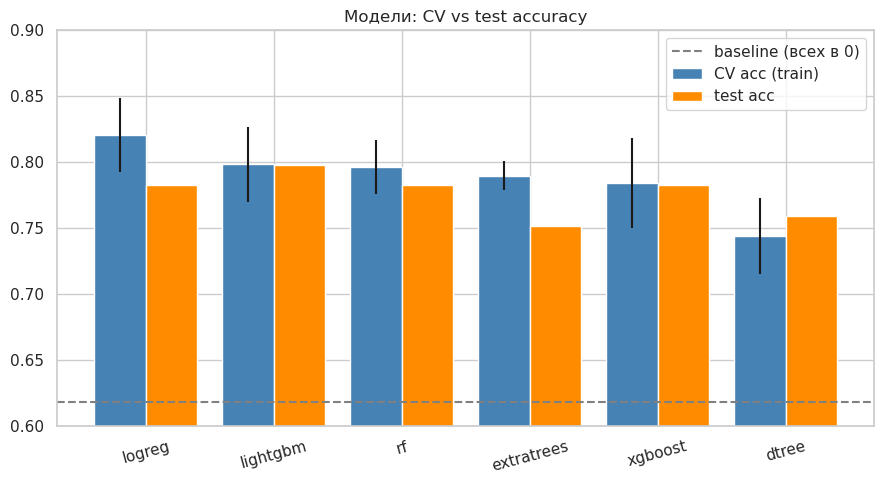

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
ax.bar(x - 0.2, results['cv_acc'], 0.4, yerr=results['cv_std'], label='CV acc (train)', color='steelblue')
ax.bar(x + 0.2, results['test_acc'], 0.4, label='test acc', color='darkorange')
ax.axhline((y == 0).mean(), ls='--', c='grey', label='baseline (всех в 0)')
ax.set_xticks(x); ax.set_xticklabels(results['model'], rotation=15)
ax.set_ylim(0.6, 0.9); ax.legend(); ax.set_title('Модели: CV vs test accuracy')
plt.tight_layout(); plt.show()

**Вывод.** Модели идут плотно: лучший CV у `logreg` (0.8204), деревья `lightgbm`/`rf`/`xgboost` рядом (CV ~0.79–0.80). Лес с параметрами по умолчанию даёт CV 0.7965 / test 0.7824 — его потенциал раскроем тюнингом в ноутбуке 03. Разрыв между CV и test небольшой → сильного переобучения нет.

**Conclusion.** Models are close; logistic regression leads on CV (0.8204), trees follow. Default forest = CV 0.7965 / test 0.7824; we tune it in notebook 03. Small CV–test gap = no strong overfitting.

## 5. Разбор леса / Forest deep dive
Матрица ошибок, ROC и важность признаков по перестановке.

In [ ]:
rf = Pipeline([('pre', tu.build_preprocessor()),
               ('clf', RandomForestClassifier(random_state=RS))]).fit(X_train, y_train)
pred = rf.predict(X_test)
print('RF test accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, target_names=['died', 'survived']))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['died', 'survived'], ax=ax[0], cmap='Blues')
ax[0].set_title('Матрица ошибок / confusion matrix')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], ls='--', c='grey'); ax[1].set_title('ROC')
plt.tight_layout(); plt.show()

In [ ]:
# Важность по перестановке честнее встроенной (не завышает редкие категории).
# Permutation importance is fairer than the built-in impurity importance.
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=RS)
imp = pd.Series(perm.importances_mean, index=tu.ALL_FEATURES).sort_values()
ax = imp.plot.barh(figsize=(8, 7), color='slateblue')
ax.set_title('Важность признаков (перестановка) / permutation importance')
plt.tight_layout(); plt.show()
print('Топ-8 / top-8:'); print(imp.sort_values(ascending=False).head(8).round(4))

In [11]:
tu.save_model(rf, 'rf_baseline')   # пригодится в ноутбуке 03 / used in notebook 03
print('сохранили / saved -> models/rf_baseline.joblib')

сохранили / saved -> models/rf_baseline.joblib


## Итог ноутбука 02 / Conclusions

- Самые важные признаки по перестановке: `sex` (0.028), `Title` (0.015), `age` (0.013), `TicketGroupSize` (0.008), `embarked` (0.008), `FarePerPerson` (0.006) — совпадает со здравым смыслом.
- Лес по умолчанию: **test 0.7824**. Класс `survived` он ловит хуже (recall 0.68) — частая картина при дисбалансе.
- `NameLength` и часть флагов слабые — окончательный разбор и отбор в ноутбуке 03 (там же SHAP).

➡️ Дальше: **ноутбук 03** — тюнинг (Optuna), SHAP, проверка доп. идей и финальное решение.